# Tutorial 4 · Weather radar: how it measures rain, and how far to trust it

**What this notebook covers.** Weather radar is the reference most opportunistic-sensing
studies compare against, and the field that merging methods adjust (Tutorial 6) and
nowcasting methods extrapolate (Tutorial 7). This notebook explains what a radar
measures, how reflectivity becomes rain, how the three radar products used in
FieldSense are stored, how to sample a radar field along a link or at a gauge, and
where radar goes wrong.

**Prerequisites.** [Tutorial 1](01_open_data.ipynb). Uses the OpenMRG and OpenRainER
example subsets; the raw OpenMRG archive and cached MRMS files are shown when present.

**Contents**
1. From echo to rain rate
2. The Z-R relation matters
3. Three radar products
4. Grids and projections
5. Rates, depths and accumulations
6. Radar along a link
7. Radar at gauges
8. Why radar is not ground truth
9. References and links

## 1. From echo to rain rate

A weather radar sends microwave pulses (S-band ~10 cm, C-band ~5 cm, X-band ~3 cm) and
measures the power scattered back by hydrometeors. For drops much smaller than the
wavelength (Rayleigh scattering) the returned power is proportional to the
**radar reflectivity factor**

$$Z = \int N(D)\,D^6\,dD \quad [\mathrm{mm^6\,m^{-3}}],$$

the sixth moment of the drop-size distribution N(D). Because Z spans many orders of
magnitude it is reported in decibels, $\mathrm{dBZ} = 10\log_{10} Z$. Rain rate is
closer to the 3.67th moment, so there is no exact conversion; an empirical power law

$$Z = a\,R^{\,b}$$

is fitted to drop-size measurements. Marshall & Palmer (1948) give $a=200$, $b=1.6$;
the US WSR-88D network uses $300R^{1.4}$ for convective rain; pysteps' default is
$316R^{1.5}$; SMHI's OpenMRG composite declares $200R^{1.5}$.

,Marshall-Palmer 200R^1.6,SMHI (OpenMRG) 200R^1.5,WSR-88D convective 300R^1.4,pysteps default 316R^1.5
dBZ,,,,
20,0.65,0.63,0.46,0.46
30,2.73,2.92,2.36,2.16
40,11.53,13.57,12.24,10.00
50,48.62,63.00,63.40,46.44


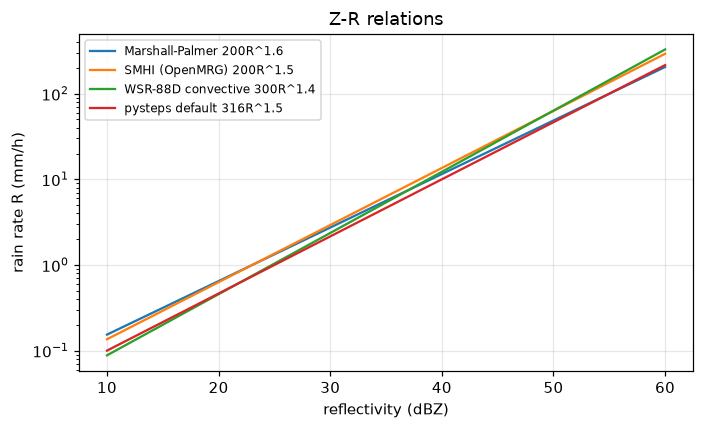

In [1]:
import contextlib
import glob
import io
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import poligrain as plg
import xarray as xr

from core import data_paths as dp
from core.opensense import example_data

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

ZR = {"Marshall-Palmer 200R^1.6": (200, 1.6), "SMHI (OpenMRG) 200R^1.5": (200, 1.5),
      "WSR-88D convective 300R^1.4": (300, 1.4), "pysteps default 316R^1.5": (316, 1.5)}
dbz = np.linspace(10, 60, 101)
fig, ax = plt.subplots(figsize=(6.5, 4))
for name, (a, b) in ZR.items():
    ax.semilogy(dbz, (10 ** (dbz / 10) / a) ** (1 / b), label=name)
ax.set(xlabel="reflectivity (dBZ)", ylabel="rain rate R (mm/h)", title="Z-R relations")
ax.legend(fontsize=8)
plt.tight_layout()

pd.DataFrame({name: (10 ** (np.array([20, 30, 40, 50]) / 10) / a) ** (1 / b) for name, (a, b) in ZR.items()},
             index=pd.Index([20, 30, 40, 50], name="dBZ")).round(2)

The relations agree within a few tenths of a mm/h at 20 dBZ and spread apart as
reflectivity grows: the exponent matters most for heavy rain - exactly where floods
come from.

## 2. The Z-R relation matters

The OpenMRG example subset carries the rain rate `R`, computed from the SMHI
reflectivity with $200R^{1.5}$. Going back to Z and forward with another relation shows
how much a hydrological total depends on that choice - here at the ten municipal gauges
over the 8-day subset:

In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    mrg = example_data.load("openmrg", "8d")
radar, gauges = mrg["radar"], mrg["gauge_municipal"]

Z = 200 * radar.R ** 1.5                                         # back to reflectivity
hourly_gauge = gauges.rainfall_amount.resample(time="1h", label="right", closed="right").sum()
at_gauges = plg.spatial.GridAtPoints(
    da_gridded_data=radar.R.isel(time=0), da_point_data=gauges.R.isel(time=0).transpose("id"),
    nnear=1, stat="best", use_lon_lat=True)

rows = []
for name, (a, b) in ZR.items():
    rate = (Z / a) ** (1 / b)                                    # mm/h, 5-min
    hourly = rate.resample(time="1h", label="right", closed="right").mean()   # mm per hour
    est = at_gauges(da_gridded_data=hourly, da_point_data=hourly_gauge.transpose("id", "time"))
    ref, e = xr.align(hourly_gauge.transpose("id", "time"), est.transpose("id", "time"))
    m = plg.validation.calculate_rainfall_metrics(reference=ref.values.ravel(), estimate=e.values.ravel(),
                                                  ref_thresh=0.1, est_thresh=0.1)
    rows.append({"Z-R": name, "8-day total, gauge mean (mm)": float(ref.sum("time").mean()),
                 "8-day total, radar at gauges (mm)": float(e.sum("time").mean()),
                 "bias (%)": m["percent_bias"], "hourly RMSE (mm)": m["root_mean_square_error"],
                 "correlation": m["pearson_correlation_coefficient"]})
pd.DataFrame(rows).set_index("Z-R").round(2)

,"8-day total, gauge mean (mm)","8-day total, radar at gauges (mm)",bias (%),hourly RMSE (mm),correlation
Z-R,,,,,
Marshall-Palmer 200R^1.6,48.91,40.52,-19.05,1.74,0.50
SMHI (OpenMRG) 200R^1.5,48.91,43.82,-12.25,1.77,0.49
WSR-88D convective 300R^1.4,48.91,36.17,-28.02,1.81,0.48
pysteps default 316R^1.5,48.91,32.30,-35.97,1.80,0.49


Correlation barely changes - each relation rescales intensities monotonically - but
the totals, and so the bias, move with it. Choosing a Z-R relation is a calibration, and
a radar product's bias at gauges is partly that choice.

## 3. Three radar products

| product | network | resolution | stored as | in FieldSense |
|---|---|---|---|---|
| SMHI composite | Swedish C-band radars, over OpenMRG | 2 km, 5 min, polar stereographic grid | reflectivity (dBZ), 8-bit integers | `core.opensense.networks.OpenMRG` |
| ARPAE composite ([ARPAE-SIMC](https://www.arpae.it)) | C-band radars of Emilia-Romagna, over OpenRainER | ~0.0125 deg (~1 km), 15 min | 15-min accumulations (mm), raw and gauge-adjusted | `core.opensense.networks.OpenRainER` |
| NOAA MRMS ([mrms.ncep.noaa.gov](https://mrms.ncep.noaa.gov/)) | all US NEXRAD radars, mosaicked; over New York | 0.01 deg (~1 km), hourly QPE | rain depth (mm); radar-only and gauge-corrected (Pass 1, Pass 2) | `core.radar.mrms` |

MRMS (Zhang et al., 2016) is a product rather than a radar: it mosaics many radars,
applies quality control and precipitation classification, and in its "MultiSensor"
QPE corrects the radar with gauges - so it is not independent of gauges either.

**The OpenMRG reflectivity encoding.** The raw OpenMRG archive stores reflectivity as
integers 0-254 with a NetCDF `scale_factor` of 0.4 and `add_offset` of -30, so
dBZ = 0.4 x stored - 30 and 255 is missing. xarray applies this when it opens the file,
so the values you see are already dBZ (from -30 upwards); applying the scaling again,
as some scripts do, gives nonsense. If the full archive is present:

In [3]:
raw_path = dp.data_path(dp.OPENMRG_RADAR)
if raw_path.exists():
    with xr.open_dataset(raw_path, mask_and_scale=False) as raw, xr.open_dataset(raw_path) as dec:
        enc = {k: raw.data.attrs[k] for k in ("scale_factor", "add_offset", "_FillValue", "zr_a", "zr_b")}
        frame = "2015-07-25 06:00"
        print("encoding attributes:", enc)
        print("stored integers at", frame, ": min", int(raw.data.sel(time=frame).min()),
              "max", int(raw.data.sel(time=frame).where(raw.data.sel(time=frame) < 255).max()))
        print("decoded dBZ          :", float(dec.data.sel(time=frame).min()), "to",
              float(dec.data.sel(time=frame).max()))
else:
    print("raw OpenMRG radar not downloaded (python -m core.opensense.fetch --dataset openmrg)")

encoding attributes: {'scale_factor': np.float32(0.4), 'add_offset': np.float32(-30.0), '_FillValue': np.int32(255), 'zr_a': '200', 'zr_b': '1.5'}
stored integers at 2015-07-25 06:00 : min 0 max 195
decoded dBZ          : -30.0 to 48.00000116229057


One frame of each product. MRMS is read from the local cache of `core.radar.mrms` when
present (fetching it needs `pip install -e ".[mrms]"` for the GRIB2 decoder).

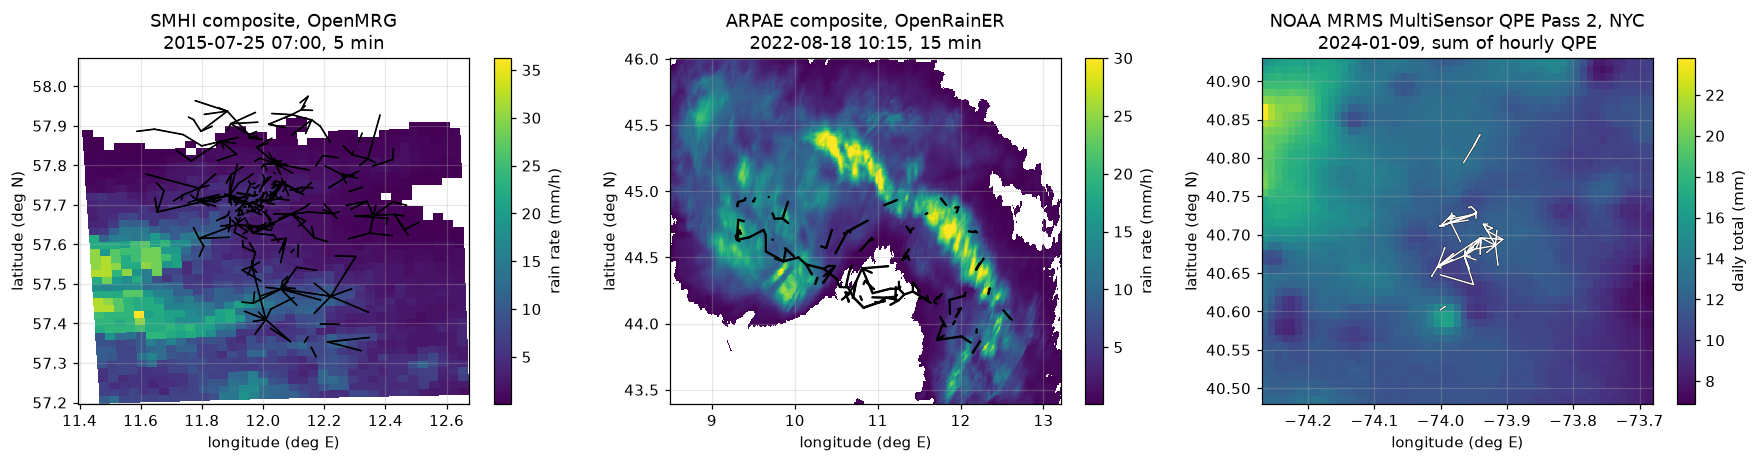

In [4]:
with contextlib.redirect_stdout(io.StringIO()):
    rainer = example_data.load("openrainer", "8d")
    mesh_cml = example_data.load("openmesh", "20d", components=("cml",))["cml"]

mrms_files = sorted(glob.glob(str(dp.data_path(dp.MRMS_CACHE) / "MultiSensor_QPE_01H_Pass2_00.00" / "nyc-*" / "2024010[9]*.nc")))
ncol = 3 if mrms_files else 2
fig, axes = plt.subplots(1, ncol, figsize=(5.4 * ncol, 4.3))

def wettest(field, cml):
    """Time step with the most rain inside the links' bounding box."""
    box = ((field.lon >= float(cml.site_0_lon.min())) & (field.lon <= float(cml.site_0_lon.max()))
           & (field.lat >= float(cml.site_0_lat.min())) & (field.lat <= float(cml.site_0_lat.max())))
    return field.time.values[int(field.where(box).mean(["y", "x"]).fillna(0).argmax())]


t_mrg = wettest(radar.R, mrg["cml"])
frame = radar.R.sel(time=t_mrg)
im = axes[0].pcolormesh(radar.lon, radar.lat, frame.where(frame > 0.1), cmap="viridis", shading="auto")
plt.colorbar(im, ax=axes[0], label="rain rate (mm/h)")
plg.plot_map.plot_lines(mrg["cml"].isel(sublink_id=0, time=0), ax=axes[0], line_color="k", line_width=0.6)
axes[0].set_title(f"SMHI composite, OpenMRG\n{pd.Timestamp(t_mrg):%Y-%m-%d %H:%M}, 5 min")

t_rainer = wettest(rainer["radar"].R, rainer["cml"])
fr = rainer["radar"].R.sel(time=t_rainer)
im = axes[1].pcolormesh(rainer["radar"].lon, rainer["radar"].lat, fr.where(fr > 0.1), cmap="viridis", vmax=30, shading="auto")
plt.colorbar(im, ax=axes[1], label="rain rate (mm/h)")
plg.plot_map.plot_lines(rainer["cml"].isel(sublink_id=0, time=0), ax=axes[1], line_color="k", line_width=1)
axes[1].set_title(f"ARPAE composite, OpenRainER\n{pd.Timestamp(t_rainer):%Y-%m-%d %H:%M}, 15 min")

if mrms_files:
    with xr.open_dataset(mrms_files[0]) as q:
        total = q["MultiSensor_QPE_01H_Pass2"].sum("time").load()
    im = axes[2].pcolormesh(total.lon, total.lat, total.where(total > 0.1), cmap="viridis", shading="auto")
    plt.colorbar(im, ax=axes[2], label="daily total (mm)")
    plg.plot_map.plot_lines(mesh_cml.isel(sublink_id=0, time=0), ax=axes[2], line_color="w", line_width=1)
    axes[2].set_title("NOAA MRMS MultiSensor QPE Pass 2, NYC\n2024-01-09, sum of hourly QPE")
for ax in axes:
    ax.set(xlabel="longitude (deg E)", ylabel="latitude (deg N)")
plt.tight_layout()

## 4. Grids and projections

Each product has its own grid. The SMHI composite is a 2 km grid on a polar
stereographic projection (declared in the file's `proj_string`); ARPAE's is a regular
latitude-longitude grid; MRMS is a regular latitude-longitude grid at 0.01 deg. The
example subsets add 2-D `lon`/`lat` coordinates and projected UTM coordinates
(`x_grid`, `y_grid`) to each grid, so every sensor can be placed in one metric plane.
Pixel sizes, computed from the UTM coordinates:

In [5]:
def pixel_km(ds):
    dx = np.abs(np.diff(ds.x_grid.values, axis=1)).mean() / 1000
    dy = np.abs(np.diff(ds.y_grid.values, axis=0)).mean() / 1000
    return round(float(dx), 2), round(float(dy), 2)


print("OpenMRG    proj:", radar.attrs.get("proj_string"), "| pixel (km):", pixel_km(radar))
print("OpenRainER grid: regular lat/lon | pixel (km):", pixel_km(rainer["radar"]))

OpenMRG    proj: +proj=stere +lat_ts=60 +ellps=bessel +lon_0=14 +lat_0=90 | pixel (km): (1.97, 1.97)
OpenRainER grid: regular lat/lon | pixel (km): (1.0, 1.0)


Distances between sensors (for interpolation, Tutorial 5) are computed in the metric
plane, never in degrees: a degree of longitude is 60 km in Gothenburg and 80 km in
Bologna. Nowcasting (Tutorial 7) also needs metric pixel sizes to turn motion vectors
into speeds.

## 5. Rates, depths and accumulations

A radar field is either a **rate** (mm/h, instantaneous or averaged over the scan
interval) or a **depth** (mm accumulated over an interval). The example subsets give
rates (`R`); OpenRainER's gauge-adjusted product is a depth per 15 minutes (`units`
says `mm`). Converting:

* depth over an interval = rate x interval length in hours (5-min rate x 5/60);
* hourly depth = the mean of the rates in the hour (for complete hours);
* every hourly product in FieldSense is **hour-ending** (Tutorial 1, section 6).

In [6]:
print("R units:", rainer["radar"].R.attrs.get("units"), "| R_gauge_adjusted units:",
      rainer["radar"].R_gauge_adjusted.attrs.get("units"))
peak = rainer["radar"].R.sel(time=t_rainer).fillna(0)
iy, ix = np.unravel_index(int(peak.argmax()), peak.shape)
cell = dict(y=iy, x=ix)                                          # the wettest cell of the frame above
window = slice(pd.Timestamp(t_rainer) - pd.Timedelta("75min"), pd.Timestamp(t_rainer) + pd.Timedelta("30min"))
pd.DataFrame({
    "R (mm/h)": rainer["radar"].R.isel(**cell).sel(time=window).to_series(),
    "depth in step (mm) = R x 0.25 h": (rainer["radar"].R.isel(**cell) * 0.25).sel(
        time=window).to_series(),
}).round(2).T

R units: mm h-1 | R_gauge_adjusted units: mm


time,2022-08-18 09:00:00,2022-08-18 09:15:00,2022-08-18 09:30:00,2022-08-18 09:45:00,2022-08-18 10:00:00,2022-08-18 10:15:00,2022-08-18 10:30:00,2022-08-18 10:45:00
R (mm/h),0.04,2.4,2.60,6.08,4.68,37.80,6.72,6.60
depth in step (mm) = R x 0.25 h,0.01,0.6,0.65,1.52,1.17,9.45,1.68,1.65


## 6. Radar along a link

To compare a radar field with a link, the radar is averaged along the path, weighting
each grid cell by the length of path inside it. poligrain computes these
*intersect weights* once for all links, as a sparse matrix, and then applies them to
every time step:

weights: {'cml_id': 364, 'y': 48, 'x': 37} | radar along links: {'time': 2304, 'cml_id': 364}


weights sum to 1.0


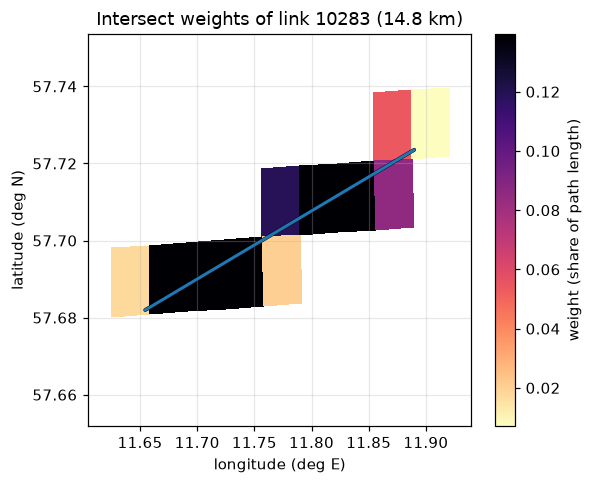

In [7]:
cml = mrg["cml"]
weights = plg.spatial.calc_sparse_intersect_weights_for_several_cmls(
    x1_line=cml.site_0_lon.values, y1_line=cml.site_0_lat.values,
    x2_line=cml.site_1_lon.values, y2_line=cml.site_1_lat.values,
    cml_id=cml.cml_id.values, x_grid=radar.lon.values, y_grid=radar.lat.values,
    grid_point_location="center")
radar_along = plg.spatial.get_grid_time_series_at_intersections(grid_data=radar.R, intersect_weights=weights)
print("weights:", dict(weights.sizes), "| radar along links:", dict(radar_along.sizes))

LINK = 10283                                                     # a 14.8 km link crossing several cells
w = weights.sel(cml_id=LINK)
w = np.asarray(w.data.todense() if hasattr(w.data, "todense") else w.data)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.pcolormesh(radar.lon, radar.lat, np.where(w > 0, w, np.nan), cmap="magma_r", shading="auto")
plt.colorbar(im, ax=ax, label="weight (share of path length)")
plg.plot_map.plot_lines(cml.sel(cml_id=[LINK]).isel(sublink_id=0, time=0), ax=ax, line_color="C0", line_width=2)
lk = cml.sel(cml_id=LINK)
lons, lats = [float(lk.site_0_lon), float(lk.site_1_lon)], [float(lk.site_0_lat), float(lk.site_1_lat)]
ax.set(xlim=(min(lons) - 0.05, max(lons) + 0.05), ylim=(min(lats) - 0.03, max(lats) + 0.03), xlabel="longitude (deg E)", ylabel="latitude (deg N)",
       title=f"Intersect weights of link {LINK} ({float(cml.length_km.sel(cml_id=LINK)):.1f} km)")
plt.tight_layout()
print("weights sum to", round(float(w.sum()), 3))

The OpenMRG example subset also carries the reference CML retrieval published with the
dataset (`R`). Hourly, all links, against the radar along their paths:

,value
pearson_correlation_coefficient,0.546
percent_bias,21.174
root_mean_square_error,1.550
mean_absolute_error,0.713
N_all,70252.000


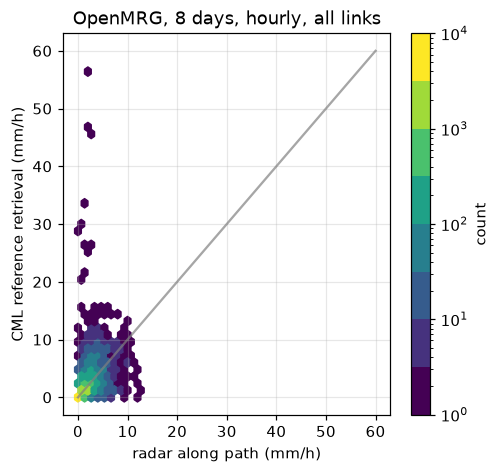

In [8]:
cml_hourly = cml.R.mean("sublink_id").resample(time="1h", label="right", closed="right").mean()
rad_hourly = radar_along.resample(time="1h", label="right", closed="right").mean()
a, b = xr.align(rad_hourly.transpose("cml_id", "time"), cml_hourly.transpose("cml_id", "time"))
m = plg.validation.calculate_rainfall_metrics(reference=a.values.ravel(), estimate=b.values.ravel(),
                                              ref_thresh=0.1, est_thresh=0.1)
fig, ax = plt.subplots(figsize=(4.8, 4.5))
plg.validation.plot_hexbin(a.values.ravel(), b.values.ravel(), ref_thresh=0.1, est_thresh=0.1, ax=ax)
ax.set(xlabel="radar along path (mm/h)", ylabel="CML reference retrieval (mm/h)",
       title="OpenMRG, 8 days, hourly, all links")
pd.Series({k: m[k] for k in ["pearson_correlation_coefficient", "percent_bias",
                            "root_mean_square_error", "mean_absolute_error", "N_all"]}).round(3).to_frame("value")

## 7. Radar at gauges

At a gauge, the radar is read from the grid cell containing it (`GridAtPoints` with
`nnear=1`; `stat="best"` with more neighbours picks the cell closest in value, a common
way to allow for small displacements). Emilia-Romagna has two radar products and 319
gauges - but the gauge-adjusted product was corrected with these same gauges, so its
score at them is not an independent test.

,correlation,bias (%),RMSE (mm/h),N
radar (raw),0.81,33.73,3.21,61567.0
radar (gauge-adjusted),0.94,-0.59,1.93,61567.0


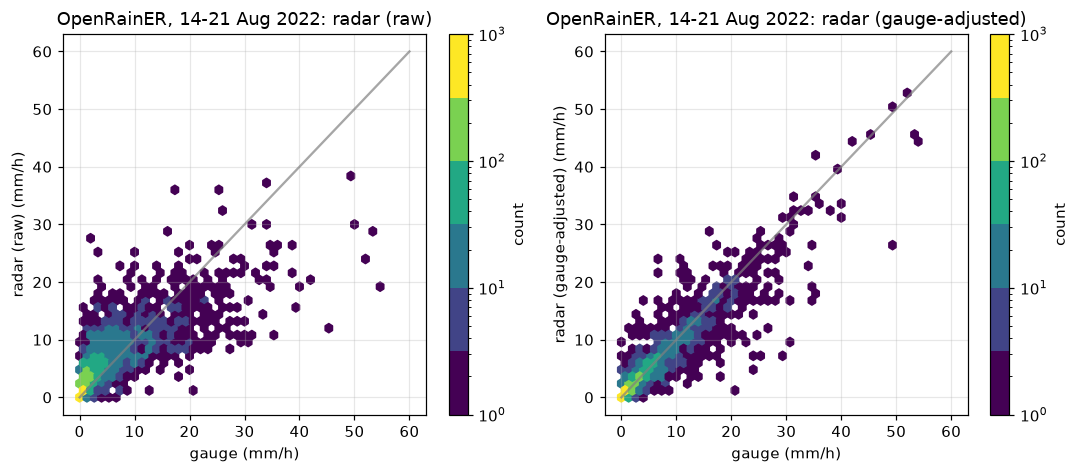

In [9]:
g = rainer["gauge"]
gauge_hourly = g.rainfall_amount.resample(time="1h", label="right", closed="right").sum(min_count=4)
products = {
    "radar (raw)": rainer["radar"].R.resample(time="1h", label="right", closed="right").mean(),
    "radar (gauge-adjusted)": rainer["radar"].R_gauge_adjusted.resample(time="1h", label="right", closed="right").sum(min_count=4),
}
pick = plg.spatial.GridAtPoints(da_gridded_data=products["radar (raw)"].isel(time=0),
                                da_point_data=gauge_hourly.isel(time=0), nnear=1, stat="best", use_lon_lat=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
rows = {}
for ax, (name, field) in zip(axes, products.items()):
    est = pick(da_gridded_data=field, da_point_data=gauge_hourly.transpose("id", "time"))
    ref, e = xr.align(gauge_hourly.transpose("id", "time"), est.transpose("id", "time"))
    plg.validation.plot_hexbin(ref.values.ravel(), e.values.ravel(), ref_thresh=0.1, est_thresh=0.1, ax=ax)
    ax.set(xlabel="gauge (mm/h)", ylabel=f"{name} (mm/h)", title=f"OpenRainER, 14-21 Aug 2022: {name}")
    m = plg.validation.calculate_rainfall_metrics(reference=ref.values.ravel(), estimate=e.values.ravel(),
                                                  ref_thresh=0.1, est_thresh=0.1)
    rows[name] = {"correlation": m["pearson_correlation_coefficient"], "bias (%)": m["percent_bias"],
                  "RMSE (mm/h)": m["root_mean_square_error"], "N": m["N_all"]}
plt.tight_layout()
pd.DataFrame(rows).T.round(2)

## 8. Why radar is not ground truth

Radar errors are well documented (Villarini & Krajewski, 2010):

* **Beam height.** The beam rises with range (Earth curvature, elevation angle); far
  from the radar it samples rain kilometres aloft, or overshoots shallow rain and snow.
  Rain can evaporate, grow or drift with the wind before it reaches the ground.
* **Bright band.** Melting snowflakes, coated with water, reflect strongly; where the
  beam crosses the melting layer, rain is overestimated.
* **Attenuation.** At C- and X-band, heavy rain near the radar attenuates the beam, so
  cells behind a storm are underestimated.
* **Clutter and blockage.** Buildings, terrain and wind farms return echoes or block
  the beam.
* **Z-R variability.** The drop-size distribution varies between and within storms
  (section 2).
* **Sampling.** A 1-2 km volume, scanned every 5-15 minutes, against a point gauge or a
  path that integrates continuously.

Gauge adjustment removes much of the bias but makes the product depend on the gauges.
FieldSense finds the consequences on each network (details and caveats in each
project's README):

* In **Gothenburg** the SMHI radar scores worse at held-out gauges than the other
  gauges do (hourly NRMSE 1.47 vs 1.10), and worse than the best link maps
  (`projects/maps/multisensor`).
* In **Emilia-Romagna** the raw ARPAE radar reads about 51% high on the study storms;
  kriging with external drift on the 319 gauges brings its NRMSE from 2.21 to 1.27
  (`projects/maps/multisensor`).
* Over **Manhattan** the links correlate +0.53 with the PWS and about 0 with the KOKX
  NEXRAD radar, whose beam passes far above the city (`projects/maps/archive_pipeline`);
  MRMS, which mosaics several radars and corrects with gauges, is the best point
  reference there (`projects/maps/nyc`, `projects/maps/multisensor`).

This is why FieldSense scores every product against the radar **and** against
gauges, and why merging (Tutorial 6) treats the radar as one more uncertain sensor.

**Next:** Tutorial 5 interpolates link and gauge observations into rain maps, and
Tutorial 6 merges them with radar.

## 9. References and links

* Marshall, J. S., and Palmer, W. M. (1948). The distribution of raindrops with size. *J. Meteor.*, 5, 165-166. [doi:10.1175/1520-0469(1948)005<0165:TDORWS>2.0.CO;2](https://doi.org/10.1175/1520-0469(1948)005<0165:TDORWS>2.0.CO;2)
* Villarini, G., and Krajewski, W. F. (2010). Review of the different sources of uncertainty in single polarization radar-based estimates of rainfall. *Surv. Geophys.*, 31, 107-129. [doi:10.1007/s10712-009-9079-x](https://doi.org/10.1007/s10712-009-9079-x)
* Zhang, J., et al. (2016). Multi-Radar Multi-Sensor (MRMS) quantitative precipitation estimation: initial operating capabilities. *Bull. Amer. Meteor. Soc.*, 97, 621-638. [doi:10.1175/BAMS-D-14-00174.1](https://doi.org/10.1175/BAMS-D-14-00174.1)
* Andersson, J. C. M., et al. (2022). OpenMRG. *Earth Syst. Sci. Data*, 14, 5411-5426. [doi:10.5194/essd-14-5411-2022](https://doi.org/10.5194/essd-14-5411-2022)
* Data providers: [SMHI](https://www.smhi.se/en), [ARPAE-SIMC](https://www.arpae.it), [NOAA MRMS](https://mrms.ncep.noaa.gov/)
* Software: [poligrain](https://poligrain.readthedocs.io) (intersect weights, grid at points, metrics), [wradlib](https://docs.wradlib.org) (radar processing in Python), [pysteps](https://pysteps.readthedocs.io) (Tutorial 7)
* In this repository: `core/radar/mrms` (MRMS client and maps), `core/radar/nexrad.py` (KOKX NEXRAD), `core/opensense/networks.py` (hourly radar for the three networks)